<a href="https://www.kaggle.com/code/martynasdiugas/stack-overflow-sql?scriptVersionId=284321858" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Stack Overflow SQL Case Study

**Author:** Martynas Džiugas  
**Goal:** Analyse the public Stack Overflow BigQuery dataset to uncover technology trends, user growth patterns, expert vs beginner behaviour, and factors that influence how quickly questions receive answers.

---

## Introduction

This project uses **pure SQL** on Google BigQuery to analyse millions of Stack Overflow posts.  
Python is used only to run SQL queries and display results — all logic and analysis happen in SQL.

The dataset includes:

- `posts_questions` — questions, tags, scores, and metadata  
- `posts_answers` — answers linked to each question  
- `users` — reputation, location, and creation dates  

The goal is to produce clear, business-style insights similar to what a data analyst or BI role would deliver, while demonstrating the ability to work with large, production-scale datasets.

---

### Key Questions

- Which technologies have grown the fastest from 2010 to 2022?
- Which tags dominate recent years (2020–2022)?
- Which countries contribute the most new Stack Overflow users?
- How do high-reputation users differ from beginners in the tags they use?
- How do question features (tag count, title length, score) affect answer speed?

---

### Key Insights

- **Modern technologies show strong long-term growth.** Python 3.x, Pandas, Node.js, AWS, and Go have grown quickly since 2010, reflecting the rise of data science, cloud services, and modern backend development.

- **Core languages still dominate recent activity.** From 2020–2022, Python, JavaScript, Java, and ReactJS remain the most common tags, showing their continued importance in day-to-day software work.

- **India and the United States add the most new users.** India often surpasses the U.S. in new registrations, highlighting the size and momentum of its developer community.

- **Experts and beginners focus on different technologies.** High-reputation users tend to work with mature, enterprise-level tools (for example .NET, Mercurial, Cocoa Touch), while beginners cluster around introductory, high-volume technologies such as VBA, Excel, Unity3D, Firebase, and basic Python tools.

- **Question structure influences answer speed.** Questions with fewer tags, shorter titles, and lower scores receive an answer faster. In contrast, highly viewed or highly upvoted posts tend to stay active longer and wait more time for their first reply.

In [1]:
from google.cloud import bigquery
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client()

def run_query(query: str) -> pd.DataFrame:
    """Helper to run a SQL query on BigQuery and return a DataFrame."""
    return client.query(query).to_dataframe()

Using Kaggle's public dataset BigQuery integration.


## Data Overview

### Methods & Filters

- Time window: questions from 2010–2022, with answer-time analysis focused on 2018–2020 or 2020 only to keep runtimes reasonable.
- Technology trends: tags must appear at least 100 times in both 2010 and 2022 to be included in growth calculations.
- Reputation buckets: `<1000` = beginners, `≥10000` = experts; everything in between is treated as mid-level.
- Answer speed: measured as the time from question creation to the **first** answer, not necessarily the accepted one.

In [2]:
data_ov1 = """
SELECT
  id,
  title,
  creation_date,
  score,
  view_count,
  tags
FROM `bigquery-public-data.stackoverflow.posts_questions`
ORDER BY creation_date
LIMIT 10
"""

run_query(data_ov1)

,id,title,creation_date,score,view_count,tags
0,4,How to convert Decimal to Double in C#?,2008-07-31 21:42:52.667000+00:00,781,67914,c#|floating-point|type-conversion|double|decimal
1,6,Why did the width collapse in the percentage w...,2008-07-31 22:08:08.620000+00:00,318,23047,html|css|internet-explorer-7
2,9,How do I calculate someone's age based on a Da...,2008-07-31 23:40:59.743000+00:00,2161,757897,c#|.net|datetime
3,11,Calculate relative time in C#,2008-07-31 23:55:37.967000+00:00,1629,193525,c#|datetime|time|datediff|relative-time-span
4,13,Determine a user's timezone,2008-08-01 00:42:38.903000+00:00,689,263594,html|browser|timezone|user-agent|timezone-offset
5,14,Difference between Math.Floor() and Math.Trunc...,2008-08-01 00:59:11.177000+00:00,482,167889,.net|math
6,16,Filling a DataSet or a DataTable from a LINQ q...,2008-08-01 04:59:33.643000+00:00,154,87067,c#|linq|web-services|.net-3.5
7,17,Binary Data in MySQL,2008-08-01 05:09:55.993000+00:00,197,84604,mysql|database|binary-data|data-storage
8,19,What is the fastest way to get the value of π?,2008-08-01 05:21:22.257000+00:00,347,65879,performance|algorithm|language-agnostic|unix|pi
9,24,Throw an error preventing a table update in a ...,2008-08-01 12:12:19.350000+00:00,192,98408,mysql|database|triggers


These early 2008 questions show that each post contains multiple technologies stored in a single `tags` string (like `c#|datetime|double`). This confirms we’ll need to split/explode tags to analyze technologies individually.

### Distribution of Technologies (Tag Frequency Across All Questions)

In [3]:
data_ov2 = """
WITH exploded AS (
  SELECT
    id,
    creation_date,
    tag
  FROM `bigquery-public-data.stackoverflow.posts_questions`,
       UNNEST(SPLIT(tags, '|')) AS tag
)
SELECT
  tag,
  COUNT(*) AS question_count
FROM exploded
GROUP BY tag
ORDER BY question_count DESC
LIMIT 20
"""

run_query(data_ov2)

,tag,question_count
0,javascript,2426570
1,python,2026601
2,java,1866055
3,c#,1559381
4,php,1445727
5,android,1386427
6,html,1146211
7,jquery,1029550
8,c++,776812
9,css,771839


These counts show the most frequently used technologies on Stack Overflow, with JavaScript, Python, Java, and C# dominating the platform across all years. This confirms strong long-term interest in general-purpose programming languages and web development ecosystems.

### Question Volume Over Time (2008–2022)

In [4]:
data_ov3 = """
SELECT
  EXTRACT(YEAR FROM creation_date) AS year,
  COUNT(*) AS questions_count
FROM `bigquery-public-data.stackoverflow.posts_questions`
GROUP BY year
ORDER BY year
"""

run_query(data_ov3)

,year,questions_count
0,2008,57569
1,2009,341651
2,2010,690840
3,2011,1189881
4,2012,1629386
5,2013,2033690
6,2014,2137435
7,2015,2196676
8,2016,2200802
9,2017,2116212


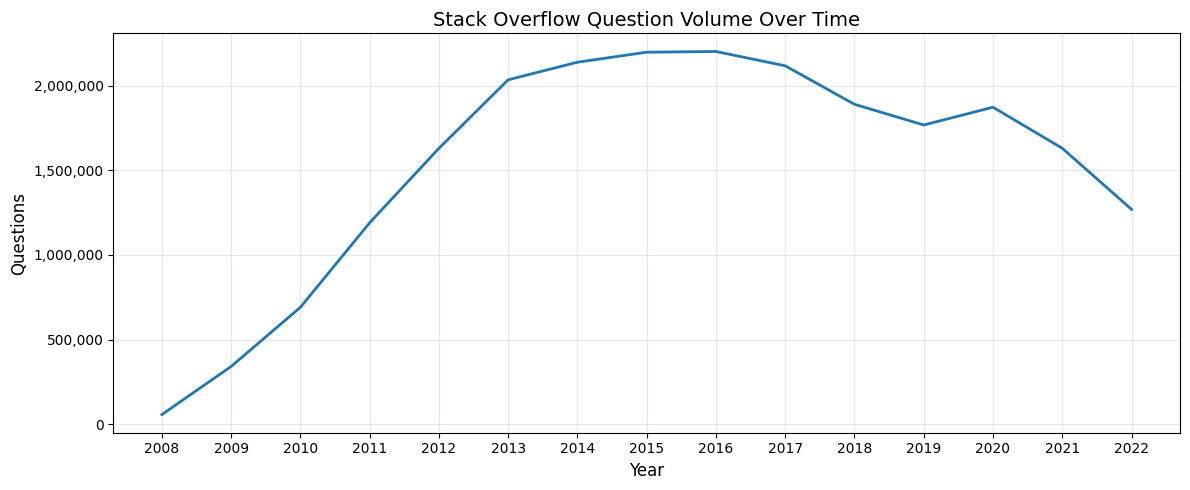

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df_year = run_query("""
SELECT
  EXTRACT(YEAR FROM creation_date) AS year,
  COUNT(*) AS questions_count
FROM `bigquery-public-data.stackoverflow.posts_questions`
GROUP BY year
ORDER BY year
""")

plt.figure(figsize=(12,5))

plt.plot(df_year['year'], df_year['questions_count'], linewidth=2)

plt.title('Stack Overflow Question Volume Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Questions', fontsize=12)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Question volume grew rapidly from 2008 to a peak around 2015–2017, then gradually declined, likely reflecting platform maturity and shifts toward alternative help channels. This gives us a clear time range where activity was highest for trend analysis.

## Technology trends over time

### Tag Growth from 2010 to 2022

In [6]:
q1 = """
WITH exploded AS (
  SELECT
    EXTRACT(YEAR FROM creation_date) AS year,
    tag
  FROM `bigquery-public-data.stackoverflow.posts_questions`,
       UNNEST(SPLIT(tags, '|')) AS tag
  WHERE EXTRACT(YEAR FROM creation_date) BETWEEN 2010 AND 2022
),

tag_year_counts AS (
  SELECT
    tag,
    year,
    COUNT(*) AS question_count
  FROM exploded
  GROUP BY tag, year
),

tag_growth AS (
  SELECT
    tag,
    MIN(CASE WHEN year = 2010 THEN question_count END) AS count_2010,
    MAX(CASE WHEN year = 2022 THEN question_count END) AS count_2022
  FROM tag_year_counts
  GROUP BY tag
),

filtered AS (
  -- Remove tags that had almost no activity in either year
  SELECT *
  FROM tag_growth
  WHERE count_2010 >= 100 AND count_2022 >= 100
),

growth_calc AS (
  SELECT
    tag,
    count_2010,
    count_2022,
    (count_2022 - count_2010) AS absolute_change,
    ROUND(((count_2022 - count_2010) / count_2010) * 100, 1) AS percent_change
  FROM filtered
)

SELECT *
FROM growth_calc
ORDER BY percent_change DESC
LIMIT 20
"""

run_query(q1)

,tag,count_2010,count_2022,absolute_change,percent_change
0,dataframe,136,20746,20610,15154.4
1,node.js,500,40314,39814,7962.8
2,python-3.x,407,27864,27457,6746.2
3,amazon-web-services,289,16694,16405,5676.5
4,go,149,6900,6751,4530.9
5,web-scraping,156,5331,5175,3317.3
6,azure,530,12292,11762,2219.2
7,ggplot2,245,4958,4713,1923.7
8,matplotlib,331,6439,6108,1845.3
9,sass,110,2100,1990,1809.1


Modern technologies like Pandas, Node.js, Python 3.x, AWS, and Go show extremely strong long-term growth from 2010 to 2022. This reflects a clear industry shift toward data science, cloud computing, and modern backend ecosystems.

### Which technologies dominate recent years (2020–2022)?

In [7]:
q2 = """
WITH exploded AS (
  SELECT
    EXTRACT(YEAR FROM creation_date) AS year,
    tag
  FROM `bigquery-public-data.stackoverflow.posts_questions`,
       UNNEST(SPLIT(tags, '|')) AS tag
  WHERE EXTRACT(YEAR FROM creation_date) BETWEEN 2020 AND 2022
)
SELECT
  tag,
  COUNT(*) AS question_count
FROM exploded
GROUP BY tag
ORDER BY question_count DESC
LIMIT 20
"""

df_q2 = run_query(q2)
df_q2

,tag,question_count
0,python,750502
1,javascript,541108
2,java,277597
3,reactjs,246929
4,c#,211050
5,html,205388
6,android,176356
7,r,152594
8,php,150538
9,node.js,150215


From 2020–2022, Python, JavaScript, Java, and ReactJS dominate question volume, showing their continued central role in modern software development. The prominence of Python, Pandas, and R also highlights strong demand for data science and analytics tools in recent years.

## Country Growth

In [8]:
#verify fields
run_query("""
SELECT *
FROM `bigquery-public-data.stackoverflow.users`
LIMIT 5
""")

,id,display_name,about_me,age,creation_date,last_access_date,location,reputation,up_votes,down_votes,views,profile_image_url,website_url
0,453,omar,None,None,2008-08-05 20:59:40.360000+00:00,2019-09-23 19:13:51.867000+00:00,United States,2150,12,0,108,https://www.gravatar.com/avatar/9cbef9b785b84e...,http://www.digitaltree.com
1,907,Naseer,<p>Engineer</p>,None,2008-08-10 09:41:10.423000+00:00,2022-09-20 21:40:06.610000+00:00,"Toronto, Canada",1705,386,15,164,None,http://linkedin.com/in/naseerahmed
2,1539,Ryan P,"<p>Software Engineer. Java, C / C++, Perl</p>",None,2008-08-16 13:31:36.823000+00:00,2016-10-22 02:03:36.057000+00:00,United States,6361,72,9,297,None,None
3,2441,aphoria,<p>.NET Developer</p>,None,2008-08-22 10:49:27.657000+00:00,2022-09-23 13:36:26.267000+00:00,None,19388,2251,9,1190,None,http://n/a
4,3826,Matt David,Currently working as a software engineer. Int...,None,2008-08-31 03:49:02.103000+00:00,2017-02-07 20:56:03.267000+00:00,Georgia,683,10,0,50,https://www.gravatar.com/avatar/4e710af23636b7...,http://mattdavid.net


In [9]:
q3 = """
WITH user_raw AS (
  SELECT
    location,
    EXTRACT(YEAR FROM creation_date) AS year
  FROM `bigquery-public-data.stackoverflow.users`
  WHERE location IS NOT NULL
    AND location != ''
    AND EXTRACT(YEAR FROM creation_date) BETWEEN 2010 AND 2022
),

-- Extract and standardize country from free-text location
country_cleaned AS (
  SELECT
    year,
    CASE
      WHEN TRIM(SPLIT(location, ',')[OFFSET(array_length(SPLIT(location, ',')) - 1)])
           IN ('US', 'USA', 'United States', 'United States of America') THEN 'United States'
      WHEN TRIM(SPLIT(location, ',')[OFFSET(array_length(SPLIT(location, ',')) - 1)])
           IN ('UK', 'United Kingdom', 'Great Britain', 'England') THEN 'United Kingdom'
      ELSE TRIM(SPLIT(location, ',')[OFFSET(array_length(SPLIT(location, ',')) - 1)])
    END AS country
  FROM user_raw
)

SELECT
  country,
  year,
  COUNT(*) AS new_users
FROM country_cleaned
WHERE country IS NOT NULL AND country != ''
GROUP BY country, year
ORDER BY new_users DESC
LIMIT 20
"""

run_query(q3)

,country,year,new_users
0,India,2017,116328
1,India,2018,104346
2,United States,2017,103653
3,United States,2018,91789
4,India,2020,87317
5,India,2019,86200
6,United States,2020,78105
7,United States,2019,76892
8,India,2021,74333
9,United States,2021,61465


India and the United States consistently contribute the largest numbers of new Stack Overflow users, with India often exceeding the U.S. in peak years. This reflects the size and activity of developer communities in both regions during the 2010–2022 period.

## Expert vs Beginner Technology Use

This section compares the technologies used by high-reputation users (experts) and low-reputation users (beginners), showing where each group is most active.

### Top Technologies Used by Experts

In [10]:
q4 = """
WITH exploded AS (
  SELECT
    q.id,
    u.reputation,
    tag
  FROM `bigquery-public-data.stackoverflow.posts_questions` AS q
  JOIN `bigquery-public-data.stackoverflow.users` AS u
    ON q.owner_user_id = u.id
  CROSS JOIN UNNEST(SPLIT(q.tags, '|')) AS tag
  WHERE u.reputation IS NOT NULL
    AND u.reputation >= 10000          -- high-reputation users
),

tag_counts AS (
  SELECT
    tag,
    COUNT(*) AS question_count
  FROM exploded
  GROUP BY tag
)

SELECT
  tag,
  question_count
FROM tag_counts
ORDER BY question_count DESC
LIMIT 20
"""

df_q4 = run_query(q4)
df_q4

,tag,question_count
0,javascript,181143
1,c#,167190
2,java,147249
3,python,116373
4,android,91178
5,jquery,88980
6,php,88785
7,c++,85499
8,html,71307
9,.net,64840


High-reputation users most often post about well-established technologies such as JavaScript, C#, Java, Python, and Android.
This suggests that expert contributors tend to spend more time in mature, widely used ecosystems rather than in newer or niche technologies.

### Technologies Used Disproportionately by Experts

In [11]:
q4b_expert = """
WITH exploded AS (
  SELECT
    q.id,
    u.reputation,
    tag
  FROM `bigquery-public-data.stackoverflow.posts_questions` AS q
  JOIN `bigquery-public-data.stackoverflow.users` AS u
    ON q.owner_user_id = u.id
  CROSS JOIN UNNEST(SPLIT(q.tags, '|')) AS tag
  WHERE u.reputation IS NOT NULL
),

-- Beginner users: reputation < 1000
beginner AS (
  SELECT
    tag,
    COUNT(*) AS beginner_count
  FROM exploded
  WHERE reputation < 1000
  GROUP BY tag
),

-- Expert users: reputation >= 10000
expert AS (
  SELECT
    tag,
    COUNT(*) AS expert_count
  FROM exploded
  WHERE reputation >= 10000
  GROUP BY tag
),

-- Combine both sides for comparison
combined AS (
  SELECT
    COALESCE(b.tag, e.tag) AS tag,
    beginner_count,
    expert_count
  FROM beginner b
  FULL OUTER JOIN expert e
    ON b.tag = e.tag
)

SELECT
  tag,
  beginner_count,
  expert_count,
  SAFE_DIVIDE(expert_count, beginner_count) AS expert_ratio
FROM combined
WHERE beginner_count > 2000      -- avoid very rare tags
  AND expert_count > 200
ORDER BY expert_ratio DESC
LIMIT 20
"""

df_q4b = run_query(q4b_expert)
df_q4b

,tag,beginner_count,expert_count,expert_ratio
0,mercurial,2415,2545,1.053830
1,.net-4.0,2529,2562,1.013049
2,asp.net-mvc-2,2643,2320,0.877790
3,cocoa-touch,10719,9057,0.844948
4,coding-style,2534,2113,0.833860
5,visual-studio-2008,5148,4277,0.830808
6,linq-to-sql,5203,3584,0.688833
7,entity-framework-4,2483,1707,0.687475
8,profiling,2150,1442,0.670698
9,clojure,6163,4115,0.667694


Expert users show a stronger presence in older, enterprise-focused technologies like Mercurial, .NET 4.0, ASP.NET MVC 2, and Cocoa Touch.
This pattern reflects deeper involvement with legacy systems and long-running production frameworks—areas where experienced developers are more commonly active.

### Technologies Used Disproportionately by Beginners

In [12]:
q4b_beginner = """
WITH exploded AS (
  SELECT
    q.id,
    u.reputation,
    tag
  FROM `bigquery-public-data.stackoverflow.posts_questions` AS q
  JOIN `bigquery-public-data.stackoverflow.users` AS u
    ON q.owner_user_id = u.id
  CROSS JOIN UNNEST(SPLIT(q.tags, '|')) AS tag
  WHERE u.reputation IS NOT NULL
),

-- Beginner users: reputation < 1000
beginner AS (
  SELECT
    tag,
    COUNT(*) AS beginner_count
  FROM exploded
  WHERE reputation < 1000
  GROUP BY tag
),

-- Expert users: reputation >= 10000
expert AS (
  SELECT
    tag,
    COUNT(*) AS expert_count
  FROM exploded
  WHERE reputation >= 10000
  GROUP BY tag
),

combined AS (
  SELECT
    COALESCE(b.tag, e.tag) AS tag,
    beginner_count,
    expert_count
  FROM beginner b
  FULL OUTER JOIN expert e
    ON b.tag = e.tag
)

SELECT
  tag,
  beginner_count,
  expert_count,
  SAFE_DIVIDE(beginner_count, expert_count) AS beginner_ratio
FROM combined
WHERE beginner_count > 50000      -- remove rare/noisy tags
  AND expert_count > 50
ORDER BY beginner_ratio DESC
LIMIT 20
"""

df_q4b_beginner = run_query(q4b_beginner)
df_q4b_beginner

,tag,beginner_count,expert_count,beginner_ratio
0,vba,173809,4540,38.283921
1,unity3d,56156,1494,37.587684
2,excel,225559,6658,33.877891
3,for-loop,56006,1710,32.752047
4,dataframe,101703,3374,30.143154
5,loops,75219,2530,29.730830
6,flutter,109520,3814,28.715260
7,wordpress,145264,5360,27.101493
8,python-3.x,255911,10113,25.305152
9,firebase,98616,4017,24.549664


Beginner activity is concentrated in high-volume, introductory technologies such as VBA, Excel, Unity3D, Python, Flutter, Firebase, and basic programming concepts like loops and dataframes.

These tags represent common starting points for new developers — areas where people experiment with automation, game development, simple scripts, and early web/mobile projects. Expert participation is much lower in these ecosystems, so beginners make up most of the activity.

## Question Features & Answer Speed

In [13]:
q5 = """
WITH answers AS (
  -- Get each answer with its parent question
  SELECT
    a.parent_id AS question_id,
    a.creation_date AS answer_date
  FROM `bigquery-public-data.stackoverflow.posts_answers` AS a
),

first_answer AS (
  -- For each question, find the earliest answer timestamp
  SELECT
    question_id,
    MIN(answer_date) AS first_answer_date
  FROM answers
  GROUP BY question_id
),

questions AS (
  SELECT
    q.id AS question_id,
    q.title,
    q.body,
    q.tags,
    q.creation_date AS question_date,
    q.score,
    q.view_count
  FROM `bigquery-public-data.stackoverflow.posts_questions` AS q
  WHERE q.creation_date BETWEEN '2020-01-01' AND '2020-12-31'   -- limit to one year
)

SELECT
  q.question_id,
  q.score,
  q.view_count,
  LENGTH(q.title) AS title_length,
  LENGTH(q.body) AS body_length,
  ARRAY_LENGTH(SPLIT(q.tags, '|')) AS tag_count,
  TIMESTAMP_DIFF(f.first_answer_date, q.question_date, HOUR) AS answer_time_hours
FROM questions q
JOIN first_answer f
  ON q.question_id = f.question_id
"""

df_q5 = run_query(q5)
df_q5.head()

,question_id,score,view_count,title_length,body_length,tag_count,answer_time_hours
0,60818048,3,527,96,943,2,0
1,60932123,1,272,100,2307,5,0
2,61107302,0,19,102,1287,1,0
3,60813632,0,28,106,850,2,0
4,60791554,0,288,127,2003,4,494


### Tag Count vs Average Answer Time

In [14]:
run_query("""
WITH data AS (
  -- same dataset as above reduced to key columns
  SELECT
    ARRAY_LENGTH(SPLIT(tags, '|')) AS tag_count,
    TIMESTAMP_DIFF(f.first_answer_date, q.creation_date, HOUR) AS answer_time_hours
  FROM `bigquery-public-data.stackoverflow.posts_questions` q
  JOIN (
    SELECT parent_id AS id, MIN(creation_date) AS first_answer_date
    FROM `bigquery-public-data.stackoverflow.posts_answers`
    GROUP BY parent_id
  ) f
  ON q.id = f.id
  WHERE q.creation_date BETWEEN '2020-01-01' AND '2020-12-31'
)
SELECT
  tag_count,
  AVG(answer_time_hours) AS avg_answer_time
FROM data
GROUP BY tag_count
ORDER BY tag_count
""")

,tag_count,avg_answer_time
0,1,212.724630
1,2,240.536897
2,3,295.057645
3,4,335.972290
4,5,363.898196


Questions with fewer tags tend to receive faster answers.
Average answer time increases consistently from ~213 hours (1 tag) to ~364 hours (5 tags), indicating that broader or multi-topic questions take longer for the community to address.

---

### Title Length vs Average Answer Time

In [15]:
run_query("""
WITH data AS (
  SELECT
    LENGTH(title) AS title_length,
    TIMESTAMP_DIFF(f.first_answer_date, q.creation_date, HOUR) AS answer_time_hours
  FROM `bigquery-public-data.stackoverflow.posts_questions` q
  JOIN (
    SELECT parent_id AS id, MIN(creation_date) AS first_answer_date
    FROM `bigquery-public-data.stackoverflow.posts_answers`
    GROUP BY parent_id
  ) f
  ON q.id = f.id
  WHERE q.creation_date BETWEEN '2020-01-01' AND '2020-12-31'
)
SELECT
  CASE
    WHEN title_length < 30 THEN "<30 chars"
    WHEN title_length < 70 THEN "30-70 chars"
    ELSE ">70 chars"
  END AS title_bucket,
  AVG(answer_time_hours) AS avg_answer_time
FROM data
GROUP BY title_bucket
ORDER BY avg_answer_time
""")

,title_bucket,avg_answer_time
0,<30 chars,231.814371
1,30-70 chars,279.705805
2,>70 chars,327.538482


Shorter titles tend to receive faster answers.

Average answer time rises from ~232 hours for titles under 30 characters to ~328 hours for titles over 70 characters, showing a clear pattern that longer titles correlate with slower responses.

---

### Score and Answer Speed

In [16]:
run_query("""
WITH first_answer AS (
  SELECT
    parent_id AS question_id,
    MIN(creation_date) AS first_answer_date
  FROM `bigquery-public-data.stackoverflow.posts_answers`
  GROUP BY parent_id
),
q AS (
  SELECT
    q.id AS question_id,
    q.score,
    TIMESTAMP_DIFF(f.first_answer_date, q.creation_date, HOUR) AS answer_time_hours
  FROM `bigquery-public-data.stackoverflow.posts_questions` q
  JOIN first_answer f
    ON q.id = f.question_id
  WHERE q.creation_date BETWEEN '2018-01-01' AND '2020-12-31'
)

SELECT
  CASE
    WHEN score < 0 THEN 'negative'
    WHEN score = 0 THEN '0'
    WHEN score BETWEEN 1 AND 5 THEN '1–5'
    ELSE '6+'
  END AS score_bucket,
  AVG(answer_time_hours) AS avg_answer_time
FROM q
GROUP BY score_bucket
ORDER BY avg_answer_time;
""")

,score_bucket,avg_answer_time
0,negative,34.113422
1,0,227.512137
2,1–5,555.815762
3,6+,1212.530980


Questions with lower scores tend to receive faster first answers.
These posts are often simple or low-effort questions that attract quick replies.

Higher-scored questions generally take longer to receive a first answer.
They tend to be more complex or interesting problems, so it takes longer for someone to write a good response.

### What Features Lead to Faster Answers?

Faster answers are consistently associated with questions that are simpler and narrower. Posts with fewer tags, shorter titles, and lower scores all receive their first answer more quickly on average.

In contrast, higher-scored questions tend to wait longer for a first answer, likely because they describe more complex or interesting problems that take longer to address.

---

## Limitations & Next Steps


### Limitations

- **Tag formatting isn’t perfectly consistent.**  
  Tags are user-generated and sometimes include typos or variations. This means technology counts are reliable for big trends but not exact at the edges.

- **Location data is free text, so country detection is approximate.**  
  Users can type anything (“London”, “UK”, “Earth”, emojis). Since there’s no fixed format, extracting a clean country requires simple rules that don’t catch every case.

- **Reputation groups are rough buckets, not strict definitions of expertise.**  
  Using `<1000` for beginners and `≥10000` for experts works well for broad patterns, but real expertise isn’t perfectly captured by a single threshold.

- **Answer-time analysis measures the first answer only.**  
  The SQL calculates how long it takes for a question to get its *first* reply. This shows community response speed but not the delay until an accepted or final answer.


### Next Steps

- **Add a few targeted visualizations.**  
  For example, a tag growth bar chart or a simple comparison chart for expert vs beginner technologies.

- **Compare first-answer time with accepted-answer time.**  
  This would show how often questions receive quick initial replies but take longer to reach a final solution.

- **Break technologies into categories (web, data, mobile) for cleaner insights.**  

- **Extend the analysis to more recent years if the dataset updates.**